# PredictiveSense AI 🚀
## Day 4 - ML Model Training
### Random Forest — RUL Prediction

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load ML-ready dataset
df = pd.read_csv(r'C:\Users\vipin nagar\OneDrive\Desktop\Internship 2026\PredictiveSense-AI\data\processed\train_final.csv')

print("✅ Data loaded!")
print(f"Shape: {df.shape}")

✅ Data loaded!
Shape: (20631, 21)


In [4]:
from sklearn.model_selection import train_test_split

# Defining features and target
X = df.drop(columns=['RUL', 'unit_id', 'cycle'])
y = df['RUL']

# Splitting data — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("✅ Data split done!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Features used:    {X_train.shape[1]}")


✅ Data split done!
Training samples: 16504
Testing samples:  4127
Features used:    18


In [5]:
from sklearn.ensemble import RandomForestRegressor

# Training Random Forest model
print("⏳ Training Random Forest... (1-2 minutes)")

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest trained successfully!")

⏳ Training Random Forest... (1-2 minutes)
✅ Random Forest trained successfully!


In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions on test data
y_pred = rf_model.predict(X_test)

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=== RANDOM FOREST RESULTS ===")
print(f"RMSE : {rmse:.2f} cycles")
print(f"MAE  : {mae:.2f} cycles")
print(f"R2   : {r2:.4f}")

=== RANDOM FOREST RESULTS ===
RMSE : 41.47 cycles
MAE  : 29.63 cycles
R2   : 0.6235


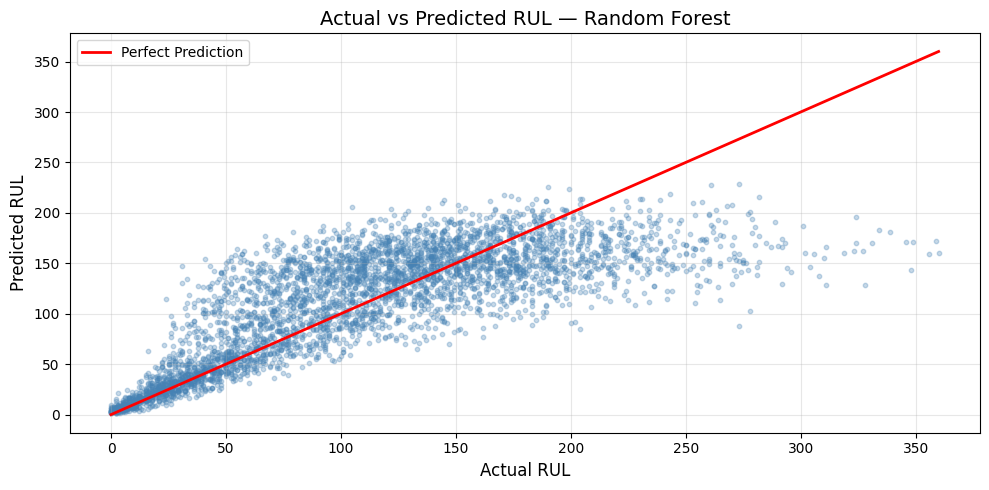

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting Actual vs Predicted RUL
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([0, 360], [0, 360], color='red', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted RUL — Random Forest', fontsize=14)
plt.xlabel('Actual RUL', fontsize=12)
plt.ylabel('Predicted RUL', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

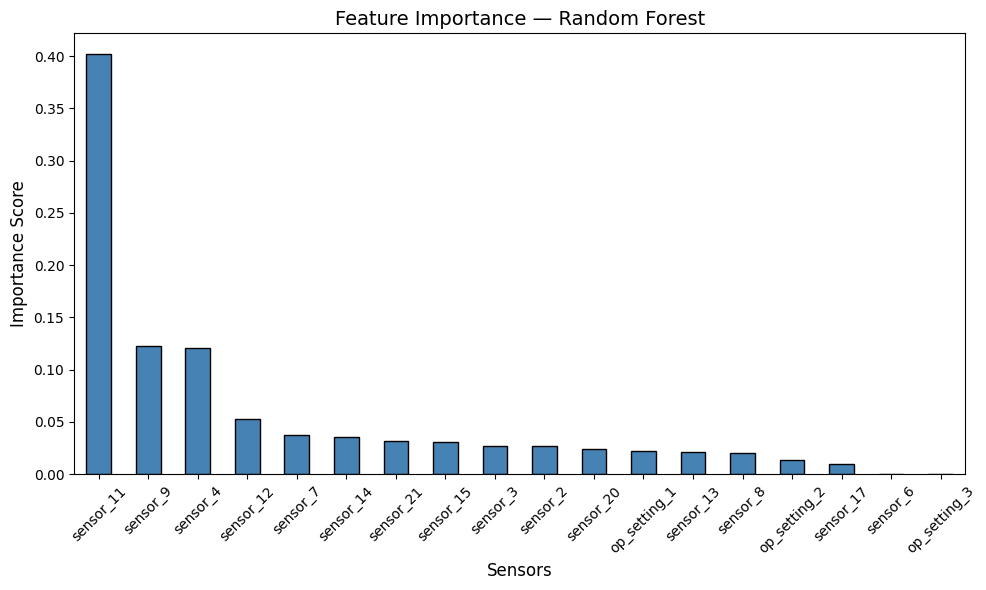


Top 5 most important sensors:
sensor_11    0.401827
sensor_9     0.122701
sensor_4     0.120905
sensor_12    0.052537
sensor_7     0.037230
dtype: float64


In [8]:
# Feature importance
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Sensors', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTop 5 most important sensors:")
print(feature_importance.head())

In [9]:
import pickle
import os

os.makedirs(r'C:\Users\vipin nagar\OneDrive\Desktop\Internship 2026\PredictiveSense-AI\models', 
            exist_ok=True)

# Saving model
with open(r'C:\Users\vipin nagar\OneDrive\Desktop\Internship 2026\PredictiveSense-AI\models\rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("✅ Model saved successfully!")
print("📁 Location: models/rf_model.pkl")

✅ Model saved successfully!
📁 Location: models/rf_model.pkl
